In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Mount Drive (if not already mounted)
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    pass

# Setup Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Mounted at /content/drive
Using device: cuda:0


In [ ]:
!cp -r /content/drive/MyDrive/dataset /content/local_dataset

In [ ]:
data_dir = '/content/local_dataset/dataset'
batch_size = 32

# Augmentation ONLY for the training folder
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Clean transforms for validation and test folders
val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

try:
    image_datasets = {
        'train': datasets.ImageFolder(os.path.join(data_dir, 'train'), train_transforms),
        'valid': datasets.ImageFolder(os.path.join(data_dir, 'valid'), val_test_transforms),
        'test': datasets.ImageFolder(os.path.join(data_dir, 'test'), val_test_transforms)
    }

    dataloaders = {
        'train': DataLoader(image_datasets['train'], batch_size=batch_size, shuffle=True, num_workers=2),
        'valid': DataLoader(image_datasets['valid'], batch_size=batch_size, shuffle=False, num_workers=2),
        'test': DataLoader(image_datasets['test'], batch_size=batch_size, shuffle=False, num_workers=2)
    }

    classes = image_datasets['train'].classes
    num_classes = len(classes)

    print("Data successfully loaded from Master Folder:")
    print(f"Train: {len(image_datasets['train'])} | Valid: {len(image_datasets['valid'])} | Test: {len(image_datasets['test'])}")
    print(f"Classes found: {classes}")
except FileNotFoundError as e:
    print(f"Error loading data: {e}\nPlease check your Drive path.")
    dataloaders = None

Data successfully loaded from Master Folder:
Train: 1000 | Valid: 36 | Test: 38
Classes found: ['Angry', 'Other', 'Sad', 'happy']


In [ ]:
import torch
import torch.nn as nn

# ==========================================
# VGG16 ARCHITECTURE
# ==========================================
def make_vgg_layers(cfg):
    layers = []
    in_channels = 3
    for v in cfg:
        if v == 'M':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        else:
            conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
            layers += [conv2d, nn.ReLU(inplace=True)]
            in_channels = v
    return nn.Sequential(*layers)

def build_vgg16(num_classes):
    cfg = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M']
    features = make_vgg_layers(cfg)
    classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512 * 7 * 7, 4096), nn.ReLU(inplace=True), nn.Dropout(),
        nn.Linear(4096, 4096), nn.ReLU(inplace=True), nn.Dropout(),
        nn.Linear(4096, num_classes)
    )
    return nn.Sequential(features, classifier)

# ==========================================
# RESNET18 ARCHITECTURE
# ==========================================
class ResidualBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return torch.relu(out)

class ResNet18_FromScratch(nn.Module):
    def __init__(self, num_classes=4):
        super(ResNet18_FromScratch, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(ResidualBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(ResidualBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(ResidualBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(ResidualBlock, 512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * ResidualBlock.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.maxpool(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        return self.fc(out)

# ==========================================
# MOBILENET (V1) ARCHITECTURE
# ==========================================
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super(DepthwiseSeparableConv, self).__init__()
        # Depthwise Convolution (groups = in_channels)
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   padding=1, stride=stride, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)

        # Pointwise Convolution (1x1)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = torch.relu(self.bn1(self.depthwise(x)))
        x = torch.relu(self.bn2(self.pointwise(x)))
        return x

class MobileNet_FromScratch(nn.Module):
    def __init__(self, num_classes=4):
        super(MobileNet_FromScratch, self).__init__()

        # Standard starting convolution
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        # The Depthwise Separable layers
        self.layers = nn.Sequential(
            DepthwiseSeparableConv(32, 64, 1),
            DepthwiseSeparableConv(64, 128, 2),
            DepthwiseSeparableConv(128, 128, 1),
            DepthwiseSeparableConv(128, 256, 2),
            DepthwiseSeparableConv(256, 256, 1),
            DepthwiseSeparableConv(256, 512, 2),

            # 5 repeating blocks of 512
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),

            DepthwiseSeparableConv(512, 1024, 2),
            DepthwiseSeparableConv(1024, 1024, 1)
        )

        # Classification Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layers(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [ ]:
def train_model(model, criterion, optimizer, num_epochs=20):
    print("\n Starting Training Loop...")
    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs} ' + '-'*15)

        for phase in ['train', 'valid']:
            model.train() if phase == 'train' else model.eval()
            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])
            print(f'{phase.capitalize()} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')

    return model

def evaluate_model(model):
    print("\n" + "="*40 + "\nEvaluating on Unseen Test Set\n" + "="*40)
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=classes, zero_division=0))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Test Set Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

 Initializing VGG16...

--- Training VGG16 ---

 Starting Training Loop...

Epoch 1/20 ---------------
Train | Loss: 1.3879 | Acc: 0.2330
Valid | Loss: 1.3886 | Acc: 0.1667

Epoch 2/20 ---------------
Train | Loss: 1.3866 | Acc: 0.2510
Valid | Loss: 1.3861 | Acc: 0.2778

Epoch 3/20 ---------------
Train | Loss: 1.3865 | Acc: 0.2580
Valid | Loss: 1.3861 | Acc: 0.2778

Epoch 4/20 ---------------
Train | Loss: 1.3867 | Acc: 0.2390
Valid | Loss: 1.3860 | Acc: 0.2778

Epoch 5/20 ---------------
Train | Loss: 1.3864 | Acc: 0.2540
Valid | Loss: 1.3860 | Acc: 0.3056

Epoch 6/20 ---------------
Train | Loss: 1.3868 | Acc: 0.2120
Valid | Loss: 1.3862 | Acc: 0.3056

Epoch 7/20 ---------------
Train | Loss: 1.3867 | Acc: 0.2480
Valid | Loss: 1.3854 | Acc: 0.3056

Epoch 8/20 ---------------
Train | Loss: 1.3865 | Acc: 0.2440
Valid | Loss: 1.3859 | Acc: 0.3056

Epoch 9/20 ---------------
Train | Loss: 1.3868 | Acc: 0.2330
Valid | Loss: 1.3853 | Acc: 0.2778

Epoch 10/20 ---------------
Train | Loss: 

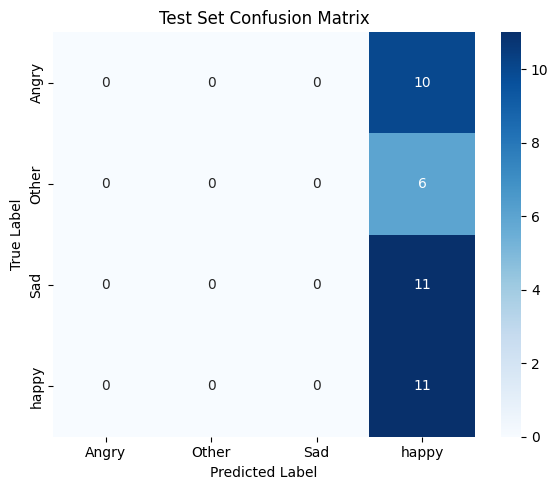

In [ ]:
# ==========================================
# EXECUTION: VGG16
# ==========================================
if dataloaders is not None:
    print(" Initializing VGG16...")

    # 1. Build Model
    vgg16_model = build_vgg16(num_classes=num_classes).to(device)

    # 2. Define Loss and Optimizer
    criterion_vgg = nn.CrossEntropyLoss()
    optimizer_vgg = optim.Adam(vgg16_model.parameters(), lr=0.0001)

    # 3. Train
    # (Adjust num_epochs to a lower number like 2 for a quick test run)
    print("\n--- Training VGG16 ---")
    vgg16_trained = train_model(vgg16_model, criterion_vgg, optimizer_vgg, num_epochs=20)

    # 4. Evaluate
    evaluate_model(vgg16_trained)
else:
    print("Cannot run execution: Dataloaders failed to initialize in Cell 2.")

 Initializing ResNet18...

--- Training ResNet18 ---

 Starting Training Loop...

Epoch 1/20 ---------------
Train | Loss: 1.4638 | Acc: 0.2530
Valid | Loss: 1.3878 | Acc: 0.3056

Epoch 2/20 ---------------
Train | Loss: 1.3998 | Acc: 0.3160
Valid | Loss: 1.4903 | Acc: 0.2778

Epoch 3/20 ---------------
Train | Loss: 1.3691 | Acc: 0.3390
Valid | Loss: 1.6220 | Acc: 0.1389

Epoch 4/20 ---------------
Train | Loss: 1.3684 | Acc: 0.3280
Valid | Loss: 1.7419 | Acc: 0.2222

Epoch 5/20 ---------------
Train | Loss: 1.3511 | Acc: 0.3390
Valid | Loss: 1.4596 | Acc: 0.2778

Epoch 6/20 ---------------
Train | Loss: 1.3072 | Acc: 0.3770
Valid | Loss: 1.3848 | Acc: 0.3056

Epoch 7/20 ---------------
Train | Loss: 1.2986 | Acc: 0.3860
Valid | Loss: 1.3273 | Acc: 0.4167

Epoch 8/20 ---------------
Train | Loss: 1.2700 | Acc: 0.4090
Valid | Loss: 1.7104 | Acc: 0.4167

Epoch 9/20 ---------------
Train | Loss: 1.2777 | Acc: 0.3920
Valid | Loss: 1.5557 | Acc: 0.3333

Epoch 10/20 ---------------
Train | 

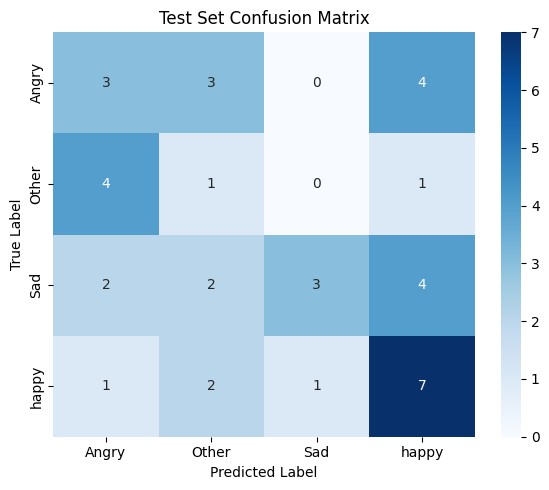

In [ ]:
# ==========================================
# EXECUTION: RESNET18
# ==========================================
if dataloaders is not None:
    print(" Initializing ResNet18...")

    # 1. Build Model
    resnet18_model = ResNet18_FromScratch(num_classes=num_classes).to(device)

    # 2. Define Loss and Optimizer
    criterion_resnet = nn.CrossEntropyLoss()
    optimizer_resnet = optim.Adam(resnet18_model.parameters(), lr=0.0001)

    # 3. Train
    # (Adjust num_epochs to a lower number like 2 for a quick test run)
    print("\n--- Training ResNet18 ---")
    resnet18_trained = train_model(resnet18_model, criterion_resnet, optimizer_resnet, num_epochs=20)

    # 4. Evaluate
    evaluate_model(resnet18_trained)
else:
    print("Cannot run execution: Dataloaders failed to initialize in Cell 2.")

 Initializing MobileNet...

--- Training MobileNet ---

 Starting Training Loop...

Epoch 1/20 ---------------
Train | Loss: 1.3909 | Acc: 0.2640
Valid | Loss: 1.4395 | Acc: 0.1667

Epoch 2/20 ---------------
Train | Loss: 1.3779 | Acc: 0.3050
Valid | Loss: 1.3110 | Acc: 0.3889

Epoch 3/20 ---------------
Train | Loss: 1.3746 | Acc: 0.3010
Valid | Loss: 1.3152 | Acc: 0.4167

Epoch 4/20 ---------------
Train | Loss: 1.3799 | Acc: 0.3000
Valid | Loss: 1.5151 | Acc: 0.1944

Epoch 5/20 ---------------
Train | Loss: 1.3761 | Acc: 0.2930
Valid | Loss: 1.3650 | Acc: 0.2500

Epoch 6/20 ---------------
Train | Loss: 1.3693 | Acc: 0.2950
Valid | Loss: 1.4662 | Acc: 0.1667

Epoch 7/20 ---------------
Train | Loss: 1.3648 | Acc: 0.3210
Valid | Loss: 1.3091 | Acc: 0.4167

Epoch 8/20 ---------------
Train | Loss: 1.3696 | Acc: 0.2790
Valid | Loss: 1.3803 | Acc: 0.2778

Epoch 9/20 ---------------
Train | Loss: 1.3660 | Acc: 0.2870
Valid | Loss: 1.3806 | Acc: 0.2222

Epoch 10/20 ---------------
Train 

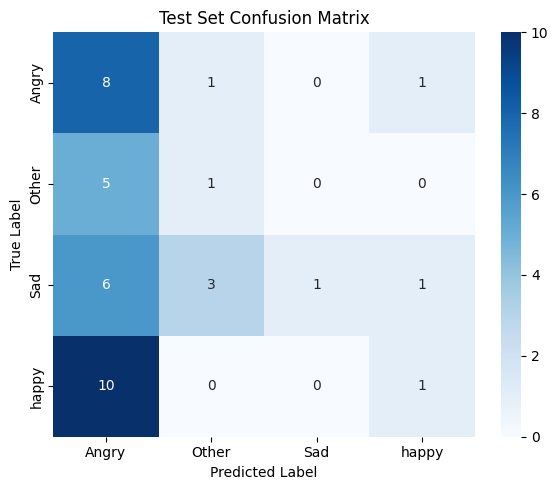

In [ ]:

# EXECUTION: MOBILENET

if dataloaders is not None:
    print(" Initializing MobileNet...")

    # 1. Build Model
    mobilenet_model = MobileNet_FromScratch(num_classes=num_classes).to(device)

    # 2. Define Loss and Optimizer
    criterion_mobile = nn.CrossEntropyLoss()
    optimizer_mobile = optim.Adam(mobilenet_model.parameters(), lr=0.0001)

    # 3. Train
    print("\n--- Training MobileNet ---")
    mobilenet_trained = train_model(mobilenet_model, criterion_mobile, optimizer_mobile, num_epochs=20)

    # 4. Evaluate
    evaluate_model(mobilenet_trained)
else:
    print("Cannot run execution: Dataloaders failed to initialize.")